# [LELEC2870] - Machine Learning
## Part 3 — Integration of Image Data



In this notebook, we integrate heart scan images into the predictive pipeline. We extract features from images using a CNN and combine them with tabular data for prediction.


In [27]:


# Standard libraries
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

# Image processing
from PIL import Image

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

### 2.1 Load Tabular and Image Data


In [67]:

import os

data_path = "/home/pj/Bureau/admin123/projet_ML/data(1)/data/data_labeled"

train_csv = os.path.join(data_path, "X_train.csv")
y_train_csv = os.path.join(data_path, "y_train.csv")
img_dir = os.path.join(data_path, "Img_train")



### 2.2 Define Custom Dataset


In [ ]:
class HeartScanDataset(Dataset):
    """Dataset for cardiac scans of the Smurfs"""
    
    def __init__(self, img_filenames, img_dir, targets=None, transform=None):
        self.img_filenames = img_filenames
        self.img_dir = img_dir
        self.targets = targets
        
        if transform is None:
            self.transform = transforms.Compose([
                transforms.Grayscale(num_output_channels=1),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.5], std=[0.5])  # [-1, 1]
            ])
        else:
            self.transform = transform
    
    def __len__(self):
        return len(self.img_filenames)
    
    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_filenames[idx])
        
        try:
            img = Image.open(img_path)
            img = self.transform(img)
            
            if self.targets is not None:
                target = torch.tensor(self.targets[idx], dtype=torch.float32)
                return img, target
            return img
        except Exception as e:
            print(f" Error loading image {img_path}: {e}")
            dummy_img = torch.zeros(1, 48, 48)
            if self.targets is not None:
                return dummy_img, torch.tensor(0.0)
            return dummy_img

# Create the full dataset
dataset_full = HeartScanDataset(images, img_dir, y)
print(f"Dataset created: {len(dataset_full)} samples")

# Test loading
sample_img, sample_label = dataset_full[0]
print(f"Image shape: {sample_img.shape}")
print(f"Label: {sample_label.item():.6f}")

# Train/Validation split (80/20)
train_size = int(0.8 * len(dataset_full))
val_size = len(dataset_full) - train_size

train_dataset, val_dataset = random_split(
    dataset_full,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"Train: {train_size} | Validation: {val_size}")

# DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)} | Validation batches: {len(val_loader)}")


✓ Dataset created: 1000 samples
✓ Image shape: torch.Size([1, 48, 48])
✓ Label: 0.060000
✓ Train: 800 | Validation: 200
✓ Train batches: 25 | Validation batches: 7


### Architecture CNN

In [60]:


class SimpleCNN(nn.Module):
    """
    Simple CNN to extract features from cardiac scans.
   """
    
    def __init__(self, n_features=8):
        super(SimpleCNN, self).__init__()
        
        # Convolutional layers
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, stride=1, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)
        
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, stride=1, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)
        
        # Fully connected layers
        self.fc1 = nn.Linear(16 * 12 * 12, n_features)
        self.fc2 = nn.Linear(n_features, 1)
        
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
    
    def forward(self, x):
        # Conv + Pool 1
        x = self.relu(self.conv1(x))
        x = self.pool1(x)
        
        # Conv + Pool 2
        x = self.relu(self.conv2(x))
        x = self.pool2(x)
        
        # Flatten
        x = x.view(x.size(0), -1)  # [batch, 16*12*12]
        
        # FC1 -> extracted features
        features = self.relu(self.fc1(x))
        features = self.dropout(features)
        
        # FC2 -> prediction
        output = self.fc2(features)
        
        return output, features

# Instantiation
n_features = 8
cnn = SimpleCNN(n_features=n_features)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
cnn = cnn.to(device)

print(f" CNN created with {n_features} extracted features")
print(f" Device: {device}")

# Number of parameters
total_params = sum(p.numel() for p in cnn.parameters())
trainable_params = sum(p.numel() for p in cnn.parameters() if p.requires_grad)
print(f" Parameters: {trainable_params:,} trainable / {total_params:,} total")


 CNN created with 8 extracted features
 Device: cpu
 Parameters: 19,697 trainable / 19,697 total


### Training of the CNN

Starting training: 20 epochs, batch_size=32, lr=0.0005

Train Loss: 0.034593 | Val Loss: 0.006192 | Best Val: 0.006192
Train Loss: 0.013232 | Val Loss: 0.006923 | Best Val: 0.006192
Train Loss: 0.009486 | Val Loss: 0.004539 | Best Val: 0.004539
Train Loss: 0.005963 | Val Loss: 0.004472 | Best Val: 0.004213
Train Loss: 0.005656 | Val Loss: 0.004112 | Best Val: 0.004092
Best validation loss: 0.004092


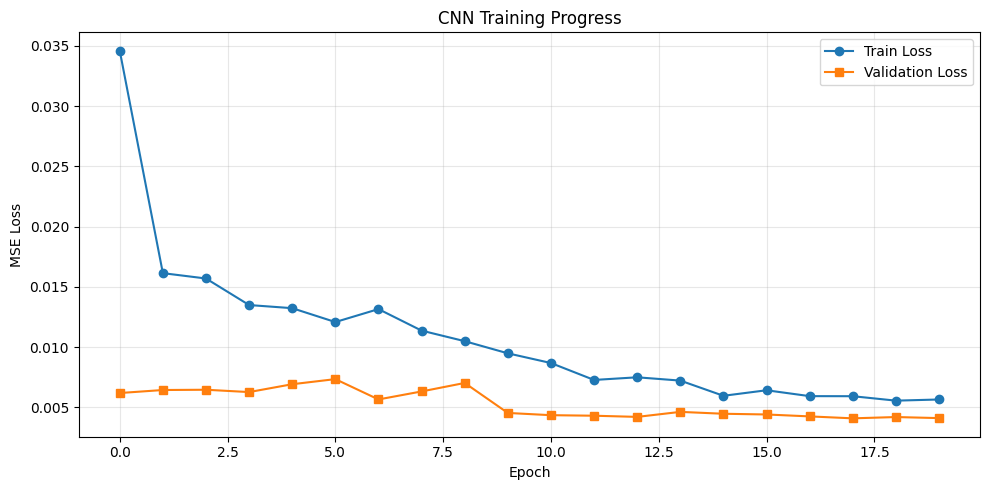

In [61]:
# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(cnn.parameters(), lr=0.0005)

# Training parameters
n_epochs = 20
best_val_loss = float('inf')

# History
train_losses = []
val_losses = []

print(f"Starting training: {n_epochs} epochs, batch_size={batch_size}, lr=0.0005\n")

for epoch in range(n_epochs):
    cnn.train()
    train_loss = 0.0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs, _ = cnn(inputs)
        loss = criterion(outputs.squeeze(), labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * inputs.size(0)
    
    train_loss /= len(train_dataset)
    train_losses.append(train_loss)
    
    cnn.eval()
    val_loss = 0.0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs, _ = cnn(inputs)
            loss = criterion(outputs.squeeze(), labels)
            val_loss += loss.item() * inputs.size(0)
    
    val_loss /= len(val_dataset)
    val_losses.append(val_loss)
    
    # best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(cnn.state_dict(), 'best_cnn_model.pth')
    
    # progress
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print( f"Train Loss: {train_loss:.6f} | "f"Val Loss: {val_loss:.6f} | "f"Best Val: {best_val_loss:.6f}")

print(f"Best validation loss: {best_val_loss:.6f}")

# Load the best model
cnn.load_state_dict(torch.load('best_cnn_model.pth'))

# Plot training curves
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('CNN Training Progress')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cnn_training_curves.png', dpi=150)
plt.show()


### Extraction of CNN features

In [62]:
# Full dataset
full_dataset = HeartScanDataset(images, img_dir, y)
full_loader = DataLoader(full_dataset, batch_size=50, shuffle=False, num_workers=0)

# Feature extraction
all_features = []
all_predictions = []

cnn.eval()
with torch.no_grad():
    for inputs, _ in full_loader:
        inputs = inputs.to(device)
        outputs, features = cnn(inputs)
        all_features.append(features.cpu().numpy())
        all_predictions.append(outputs.squeeze().cpu().numpy())

image_features = np.vstack(all_features)
cnn_predictions = np.concatenate(all_predictions)

print(f"Extracted features: {image_features.shape}")

# CNN performance
cnn_rmse = np.sqrt(mean_squared_error(y, cnn_predictions))
cnn_r2 = r2_score(y, cnn_predictions)
cnn_mae = mean_absolute_error(y, cnn_predictions)

print(f"  - RMSE: {cnn_rmse:.6f}")
print(f"  - R²:   {cnn_r2:.4f}")
print(f"  - MAE:  {cnn_mae:.6f}")


Extracted features: (1000, 8)
  - RMSE: 0.061250
  - R²:   0.4253
  - MAE:  0.041292


### Combination with tabular data

In [63]:
# Combine features
X_combined = np.hstack([X_tabular.values, image_features])
print(f"✓ X_combined shape: {X_combined.shape}")
print(f"  - Tabular features: {X_tabular.shape[1]}")
print(f"  - Image features: {image_features.shape[1]}")
print(f"  - Total: {X_combined.shape[1]}")


✓ X_combined shape: (1000, 17)
  - Tabular features: 9
  - Image features: 8
  - Total: 17


### Final model and evaluations

Train: 800 | Test: 200

RandomForest training
Trained model
Train  - RMSE: 0.018463 | R²: 0.9506
Test   - RMSE: 0.036253 | R²: 0.7368
CNN only    - RMSE: 0.061250
Combined RF - RMSE: 0.036253
Improvement: 40.81%


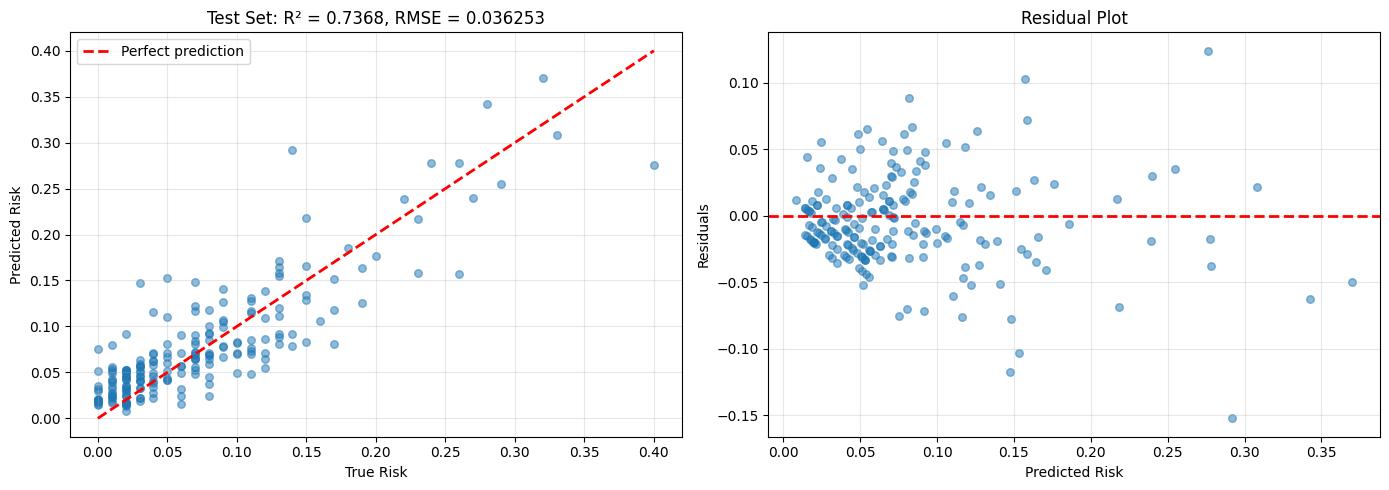

1. CNN trained: 20 epochs, 8 extracted features
2. CNN only performance: RMSE = 0.061250
3. Combined features: 17 dimensions
4. Final model (RF): RMSE = 0.036253, R² = 0.7368
5. Improvement: 40.81%


In [66]:
from sklearn.preprocessing import StandardScaler

# Split Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

# Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nRandomForest training")
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)
print("Trained model")

# Predictions
y_train_pred = rf_model.predict(X_train_scaled)
y_test_pred = rf_model.predict(X_test_scaled)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Train  - RMSE: {train_rmse:.6f} | R²: {train_r2:.4f}")
print(f"Test   - RMSE: {test_rmse:.6f} | R²: {test_r2:.4f}")

# Comparison
print(f"CNN only    - RMSE: {cnn_rmse:.6f}")
print(f"Combined RF - RMSE: {test_rmse:.6f}")
print(f"Improvement: {((cnn_rmse - test_rmse) / cnn_rmse * 100):.2f}%")

# Final plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Predictions vs True
axes[0].scatter(y_test, y_test_pred, alpha=0.5, s=30)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('True Risk')
axes[0].set_ylabel('Predicted Risk')
axes[0].set_title(f'Test Set: R² = {test_r2:.4f}, RMSE = {test_rmse:.6f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals
residuals = y_test - y_test_pred
axes[1].scatter(y_test_pred, residuals, alpha=0.5, s=30)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Risk')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('part3_final_results.png', dpi=150)
plt.show()

# Final results summary
print(f"1. CNN trained: {n_epochs} epochs, {n_features} extracted features")
print(f"2. CNN only performance: RMSE = {cnn_rmse:.6f}")
print(f"3. Combined features: {X_combined.shape[1]} dimensions")
print(f"4. Final model (RF): RMSE = {test_rmse:.6f}, R² = {test_r2:.4f}")
print(f"5. Improvement: {((cnn_rmse - test_rmse) / cnn_rmse * 100):.2f}%")



- Compare performance with and without image features  
- Discuss importance of image-derived features  
- Observations on t-SNE embedding of CNN features vs raw pixels  
